# Example of the stationary bootstrap algorithm in practice

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stationary_bootstrap import stationary_bootstrap
from stationary_bootstrap_calibrate import OptimalLength
%matplotlib inline

## Goal

The goal of this workbook is to demonstrate the use of the stationary bootstrap algorithm. In this example, 3 new samples are generated.

In [2]:
nSample = 3 # Number of generated samples
np.random.seed(1) # Makes the random samples reproducible

EURO denominated 6M interest-rate-swap rate obtained from https://www.teleborsa.it/Quotazioni/Tassi/Eurirs for date 12/11/2021 and interpolated using the Smith & Wilson algorithm for missing durations. The rates are par rates of swaps with an annual fixed leg, for maturities of 1 to 30 years.

In [3]:
swap = pd.DataFrame({'Swap rate': [-0.00497999999999998,
-0.00336999999999998,
-0.00219000000000003,
-0.00137999999999994,
-0.000839999999999952,
-0.000349999999999961,
0.000140000000000029,
0.000669999999999948,
0.00116999999999989,
0.00165999999999999,
0.00208999999999993,
0.00245999999999991,
0.00277690952371801,
0.00303541131903184,
0.00323000000000007,
0.00336225372994803,
0.00345212702349018,
0.00351682745133952,
0.00356726077755898,
0.00360999999999989,
0.00364393467821089,
0.00365001038370538,
0.00360991273768496,
0.00350996855727703,
0.00333999999999990,
0.00310968998405592,
0.00288888447388769,
0.00274107227669318,
0.00271077735186531,
0.00283000000000011]})

In [4]:
swap.head()

,Swap rate
0,-0.00498
1,-0.00337
2,-0.00219
3,-0.00138
4,-0.00084


The swap rates cannot be resampled directly, because each rate describes the whole period from today to its maturity. Instead, the curve is converted into 1-year forward rates, which describe consecutive one-year periods and can be resampled.

First, the discount factors $DF(n)$ for maturities of $n$ years are bootstrapped from the par swap rates $S(n)$:

$$DF(1) = \frac{1}{1 + S(1)}, \qquad DF(n) = \frac{1 - S(n) \sum_{i=1}^{n-1} DF(i)}{1 + S(n)}$$

The 1-year forward rate from year $n$ to year $n+1$ is then

$$fwd(n) = \frac{DF(n)}{DF(n+1)} - 1$$

Note that one observation is lost: 30 swap rates give 29 forward rates.

In [5]:
S = swap["Swap rate"].values
DF = np.zeros(len(S)) # DF[n] is the discount factor for a maturity of n+1 years
for n in range(len(S)):
    DF[n] = (1 - S[n] * DF[:n].sum()) / (1 + S[n])

In [6]:
forwards = pd.DataFrame({'Forward rate': DF[:-1] / DF[1:] - 1}) # forwards[n] is the rate from year n+1 to year n+2

In [7]:
forwards.head()

,Forward rate
0,-0.001763
1,0.000168
2,0.001051
3,0.001324
4,0.002109


The average block length m is calculated with the method presented in the 2004 paper by Politis & White.

In [8]:
m = OptimalLength(forwards["Forward rate"].values)
m

3.9401176620093596

Generate stationary bootstrapped samples

In this step, the samples are generated by repeatedly calling the stationary_bootstrap function. Each sample has the same length as the forward curve. The samples are saved as the columns of the Samples table.

In [9]:
sampleLen = len(forwards) # Length of each sample is the same as the forward curve
Samples = pd.DataFrame({iSample: stationary_bootstrap(forwards["Forward rate"].values, m, sampleLen) for iSample in range(nSample)})

In [10]:
Samples.head()

,0,1,2
0,0.004416,0.002109,0.005225
1,0.005225,0.003098,0.006703
2,0.003098,0.004416,0.006519
3,0.004669,0.005225,0.006519
4,0.004520,0.006490,0.006064


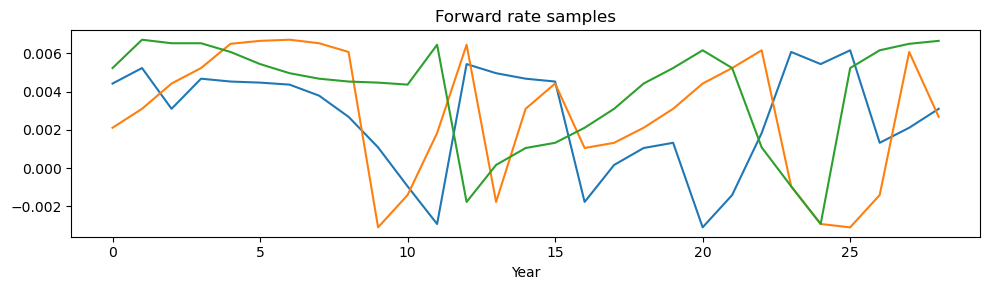

In [11]:
plot_data = Samples.to_numpy()
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(plot_data)
ax.set_title('Forward rate samples')
ax.set_xlabel('Year')
fig.tight_layout()